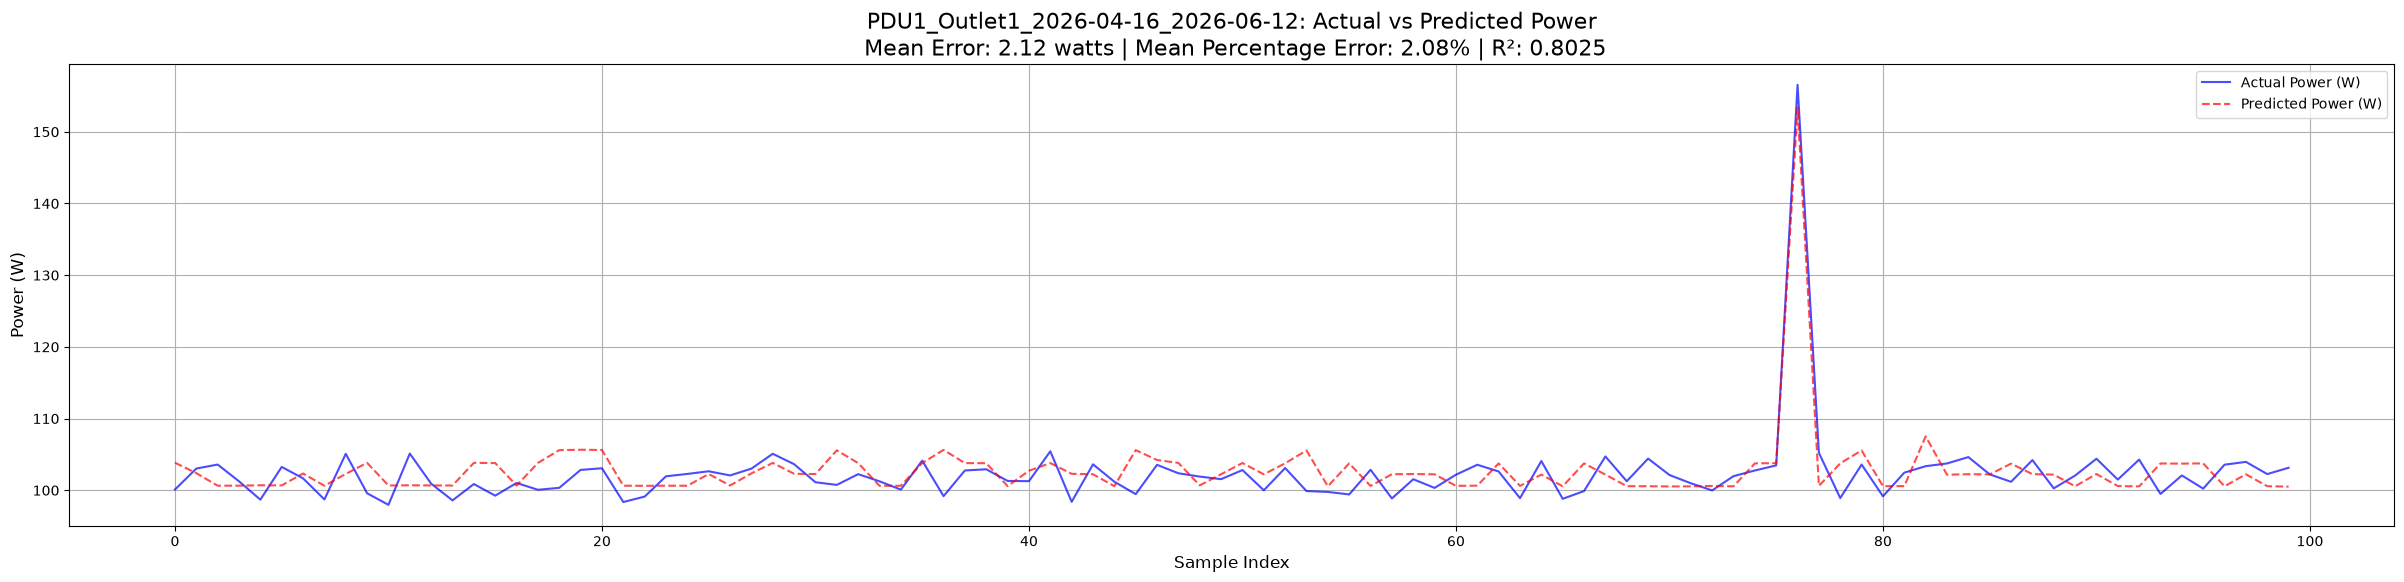

In [1]:
import json
import pandas as pd
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score

# 1. 設定檔案路徑
data_path = 'PDU1_Outlet7_2026-04-16_2026-06-12_sample_data.json'
scaler_path = 'PDU1_Outlet7_2026-04-16_2026-06-12_model_scaler.json'
onnx_path = 'power_eq_model_PDU1_Outlet7_2026-04-16_2026-06-12.onnx'

# 2. 讀取樣本資料
with open(data_path, 'r') as f:
    data = json.load(f)
df = pd.DataFrame(data)

# 3. 讀取 Scaler 參數
with open(scaler_path, 'r') as f:
    scaler = json.load(f)

feature_cols = scaler['feature_cols']
x_mins = np.array(scaler['x_mins'])
x_ranges = np.array(scaler['x_data_ranges'])
y_min = scaler['y_min']
y_range = scaler['y_data_range']

# 4. 針對特徵進行 Min-Max 正規化 (Scaling)
X_scaled_df = pd.DataFrame()
for i, col in enumerate(feature_cols):
    X_scaled_df[col] = (df[col] - x_mins[i]) / x_ranges[i]

# 5. 根據 Scaler JSON 中的分類，取出 ONNX 模型所需的三個 Input
x_core = X_scaled_df[scaler['core_indices']].values.astype(np.float32)
x_direct = X_scaled_df[scaler['direct_indices']].values.astype(np.float32)
x_other = X_scaled_df[scaler['other_indices']].values.astype(np.float32)

y_true = df['ACTUAL_POWER_W'].values

# 6. 載入並執行 ONNX 模型預測
session = ort.InferenceSession(onnx_path)
inputs = {
    'x_core': x_core,
    'x_direct': x_direct,
    'x_other': x_other
}
y_pred_scaled = session.run(None, inputs)[0]

# 7. 將預測結果反向正規化 (Inverse Scaling) 以取得實際功耗數值
y_pred = y_pred_scaled.flatten() * y_range + y_min

# 計算最終的誤差指標
mae_loss = mean_absolute_error(y_true, y_pred)
mape_loss = mean_absolute_percentage_error(y_true, y_pred) * 100
r2 = r2_score(y_true, y_pred)

# 8. 繪製實際功耗與預測功耗的對比圖
plt.figure(figsize=(30, 6))

plt.plot(y_true, label='Actual Power (W)', color='blue', alpha=0.7)
plt.plot(y_pred, label='Predicted Power (W)', color='red', alpha=0.7, linestyle='--')

name_data = "PDU1_Outlet1_2026-04-16_2026-06-12"
plt.title(f'{name_data}: Actual vs Predicted Power\n Mean Error: {mae_loss:.2f} watts | Mean Percentage Error: {mape_loss:.2f}% | R²: {r2:.4f}', fontsize=16)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Power (W)', fontsize=12)
plt.legend()
plt.grid(True)

# 顯示圖表 (不儲存圖片)
plt.show()


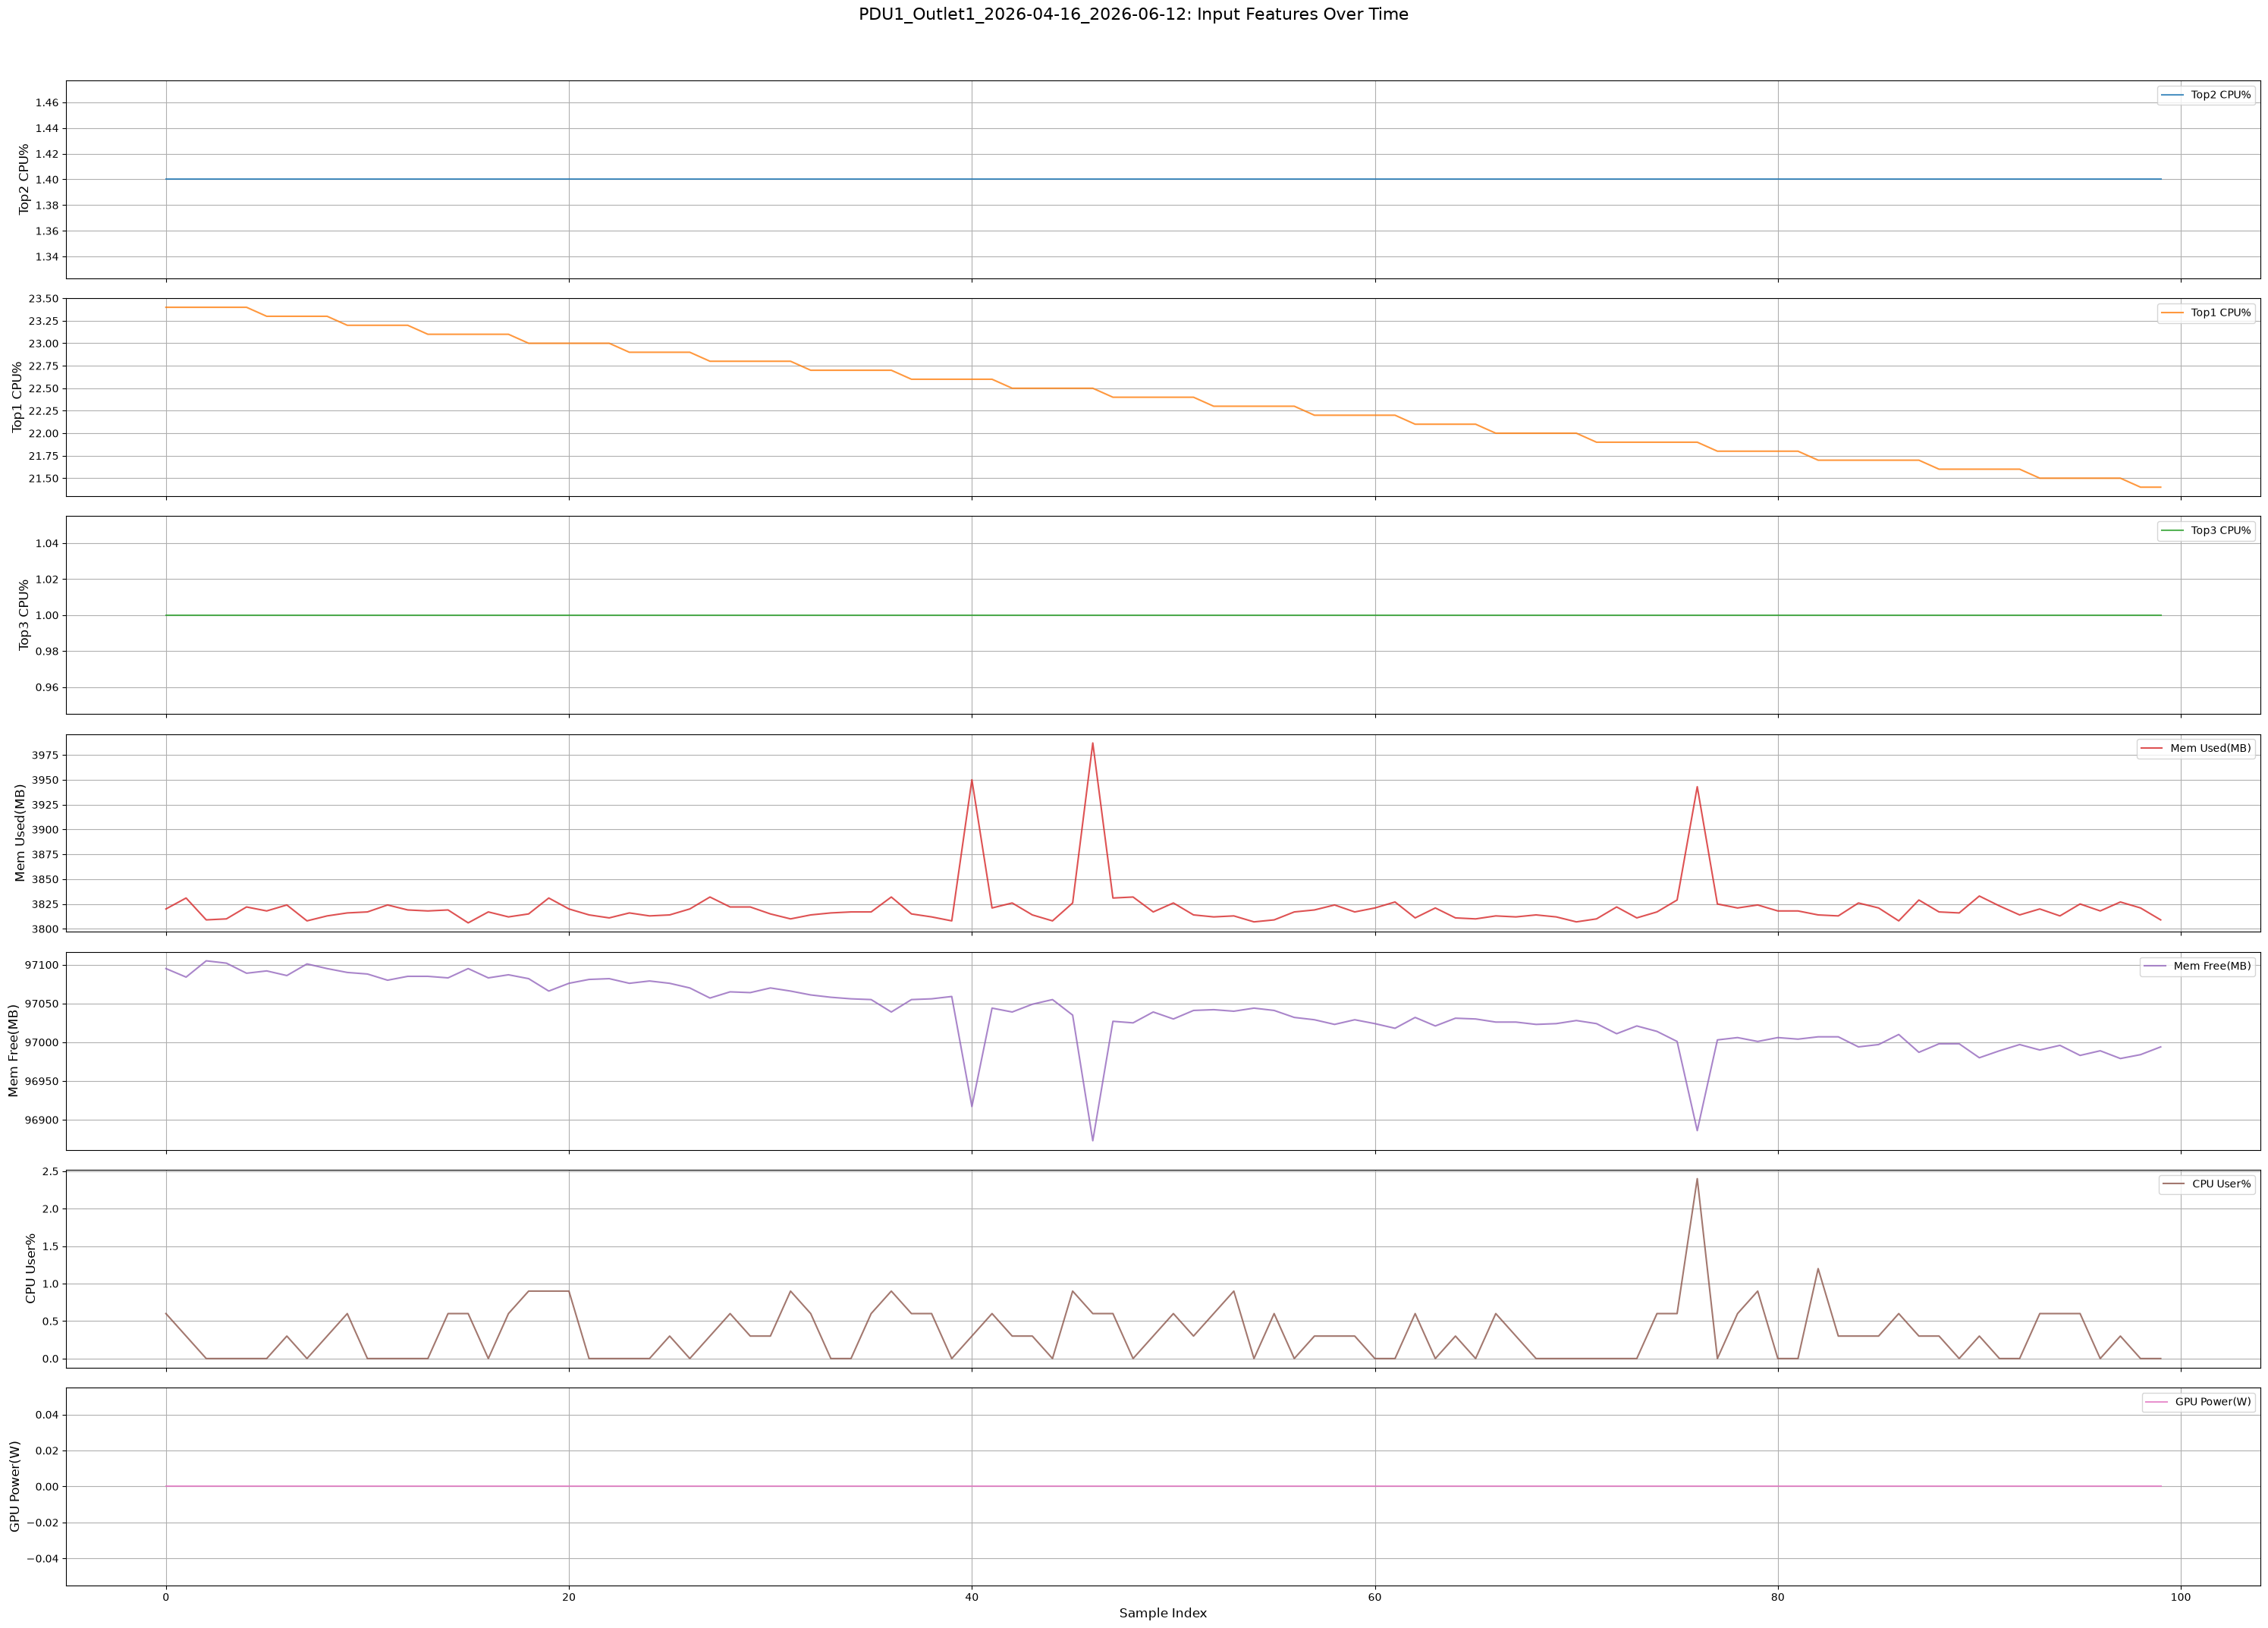

In [2]:
num_features = len(feature_cols)
# 依照特徵數量建立對應數量的子圖 (每個特徵一張圖，垂直排列)
fig, axes = plt.subplots(num_features, 1, figsize=(30, 3 * num_features), sharex=True)
for i, col in enumerate(feature_cols):
    axes[i].plot(df[col], label=col, color=f"C{i}", alpha=0.8)
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].legend(loc='upper right')
    axes[i].grid(True)
axes[-1].set_xlabel('Sample Index', fontsize=12)
plt.suptitle(f'{name_data}: Input Features Over Time', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()